In [1]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.3 MB/s eta 0:00:00


#Import Library

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from prophet.plot import plot_plotly
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg,ARResults
nlag = 40
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

#Read Data

In [3]:
df = pd.read_excel("https://raw.github.com/ilhamluk/python-data-analys/main/forecasting.xlsx")
df.head()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
0,19272,2013-01-11,AUTOMOTIVE,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
1,953040,2014-06-20,AUTOMOTIVE,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.36,12440.0,8500.0,112.0,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
2,1452,2013-01-01,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
3,26400,2013-01-15,AUTOMOTIVE,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
4,5016,2013-01-03,AUTOMOTIVE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#URUTKAN TANGGAL BERDASARKAN CATEGORY
df=df.sort_values(['category','date'])

In [5]:
df.head()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
2,1452,2013-01-01,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
110,3234,2013-01-02,AUTOMOTIVE,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
4,5016,2013-01-03,AUTOMOTIVE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
310,6798,2013-01-04,AUTOMOTIVE,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
5,8580,2013-01-05,AUTOMOTIVE,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN


#DATA UNDERSTANDING

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55572 entries, 2 to 55216
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         55572 non-null  int64         
 1   date                       55572 non-null  datetime64[ns]
 2   category                   55572 non-null  object        
 3   qty                        55572 non-null  float64       
 4   year                       0 non-null      float64       
 5   month                      0 non-null      float64       
 6   day_of_month               0 non-null      float64       
 7   day_of_week                0 non-null      float64       
 8   week_of_year               0 non-null      float64       
 9   quarter                    0 non-null      float64       
 10  is_weekend                 0 non-null      float64       
 11  day_name                   0 non-null      float64       
 12  is_payday

In [7]:
df.describe()

,id,date,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
count,5.557200e+04,55572,55572.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55572.000000,55572.000000,55572.000000,55572.000000,55572.00000,55572.000000,0.0,55572.000000,55572.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,1.501021e+06,2015-04-24 08:27:04.703087872,477.613744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087292,5.483688,12916.139549,7292.695962,114.92696,31363.636364,NaN,0.293943,0.032660,NaN,NaN,NaN,NaN,NaN,NaN
min,1.452000e+03,2013-01-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.020000,12039.000000,6500.000000,108.50000,12000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.512365e+05,2014-02-26 18:00:00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.350000,12339.000000,6550.000000,111.40000,25000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.501021e+06,2015-04-24 12:00:00,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.610000,13229.000000,7400.000000,114.40000,25000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.250806e+06,2016-06-19 06:00:00,281.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,8.360000,13366.000000,7650.000000,118.00000,25000.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,3.000590e+06,2017-08-15 00:00:00,35279.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,8.380000,13629.000000,8500.000000,122.60000,95000.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,8.662894e+05,NaN,1538.413443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282265,2.524774,528.398062,768.210449,3.95312,17915.480829,NaN,0.455570,0.177748,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,55572
month,55572
day_of_month,55572
day_of_week,55572
week_of_year,55572
quarter,55572


In [10]:
df.groupby('category')['category_group'].unique()

,category_group
category,
AUTOMOTIVE,[Automotive]
BABY CARE,[Baby & Kids]
BEAUTY,[Beauty & Health]
BEVERAGES,[Food & Beverage]
BOOKS,[Lifestyle]
BREAD/BAKERY,[Food & Beverage]
CELEBRATION,[Lifestyle]
CLEANING,[Household]
DAIRY,[Food & Beverage]


#FEATURE ENGINERING

In [11]:
#MENGISI KOLOM TANGGAL
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week
df['quarter'] = df['date'].dt.quarter
df['day_name']= df['date'].dt.day_name()
df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday']).astype(int)


In [12]:
#Periode Gajian
df['is_payday_period']= (df['date'].dt.day>=25) | (df['date'].dt.day <=5).astype(int)

In [13]:
#Harbolnas
df['event_harbolnas']= (
    ((df['month']==1) & (df['date'].dt.day==1))|
    ((df['month']==2) & (df['date'].dt.day==2))|
    ((df['month']==3) & (df['date'].dt.day==3))|
    ((df['month']==4) & (df['date'].dt.day==4))|
    ((df['month']==5) & (df['date'].dt.day==5))|
    ((df['month']==6) & (df['date'].dt.day==6))|
    ((df['month']==7) & (df['date'].dt.day==7))|
    ((df['month']==8) & (df['date'].dt.day==8))|
    ((df['month']==9) & (df['date'].dt.day==9))|
    ((df['month']==10) & (df['date'].dt.day==10))|
    ((df['month']==11) & (df['date'].dt.day==11))|
    ((df['month']==12) & (df['date'].dt.day==12))
).astype(int)


In [14]:
#Revenue
df['revenue']=df['qty']*df['avg_price']

In [15]:
#Mengisi lag qty(nilai qty pada penjualan sebelumnya)
df['lag_1_qty']=(df.groupby('category')['qty'].shift(1))
df['lag_7_qty']=(df.groupby('category')['qty'].shift(7))
df['rolling_avg_7_qty']=(df.groupby('category')['qty'].transform(lambda x: x.shift(1).rolling(7).mean().round(2)))
#

In [16]:
#Mengisi lag revenue(nilai revenue penjuaan sebelumnya) dihitung per categori
df['lag_1_revenue'] = (df.groupby('category')['revenue'].shift(1))
df['lag_7_revenue'] = (df.groupby('category')['revenue'].shift(7))
df['rolling_avg_7_revenue'] = (df.groupby('category')['revenue'].transform(lambda x: x.shift(1).rolling(7).mean().round(2)))


In [17]:
df.tail()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
55212,2993462,2017-08-11,SEAFOOD,9.0,2017,8,11,4,32,3,0,Friday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,225000.0,0,0,Food & Beverage,7.0,13.0,11.14,175000.0,325000.0,278571.43
55213,2995244,2017-08-12,SEAFOOD,8.0,2017,8,12,5,32,3,1,Saturday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,200000.0,1,0,Food & Beverage,9.0,8.0,10.57,225000.0,200000.0,264285.71
55214,2997026,2017-08-13,SEAFOOD,13.0,2017,8,13,6,32,3,1,Sunday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,325000.0,1,0,Food & Beverage,8.0,16.0,10.57,200000.0,400000.0,264285.71
55215,2998808,2017-08-14,SEAFOOD,12.0,2017,8,14,0,33,3,0,Monday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,300000.0,0,0,Food & Beverage,13.0,9.0,10.14,325000.0,225000.0,253571.43
55216,3000590,2017-08-15,SEAFOOD,10.0,2017,8,15,1,33,3,0,Tuesday,False,0,0,3.61,13411.0,7650.0,122.6,25000.0,250000.0,0,0,Food & Beverage,12.0,16.0,10.57,300000.0,400000.0,264285.71


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55572 entries, 2 to 55216
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         55572 non-null  int64         
 1   date                       55572 non-null  datetime64[ns]
 2   category                   55572 non-null  object        
 3   qty                        55572 non-null  float64       
 4   year                       55572 non-null  int32         
 5   month                      55572 non-null  int32         
 6   day_of_month               55572 non-null  int32         
 7   day_of_week                55572 non-null  int32         
 8   week_of_year               55572 non-null  UInt32        
 9   quarter                    55572 non-null  int32         
 10  is_weekend                 55572 non-null  int64         
 11  day_name                   55572 non-null  object        
 12  is_payday

#Missing Value

In [19]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,0
month,0
day_of_month,0
day_of_week,0
week_of_year,0
quarter,0


#MISSING VALUE

In [20]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,0
month,0
day_of_month,0
day_of_week,0
week_of_year,0
quarter,0


In [21]:
#Mengisi nilai kosong dengan 0
df= df.fillna(0)

In [22]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,0
month,0
day_of_month,0
day_of_week,0
week_of_year,0
quarter,0


#UBAH TYPE DATA

In [23]:
df['qty']= df['qty'].astype(int)
df['is_payday_period'] = df['is_payday_period'].astype(int)
df['lag_1_qty']=df['lag_1_qty'].astype(int)
df['lag_7_qty']=df['lag_7_qty'].astype(int)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55572 entries, 2 to 55216
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         55572 non-null  int64         
 1   date                       55572 non-null  datetime64[ns]
 2   category                   55572 non-null  object        
 3   qty                        55572 non-null  int64         
 4   year                       55572 non-null  int32         
 5   month                      55572 non-null  int32         
 6   day_of_month               55572 non-null  int32         
 7   day_of_week                55572 non-null  int32         
 8   week_of_year               55572 non-null  UInt32        
 9   quarter                    55572 non-null  int32         
 10  is_weekend                 55572 non-null  int64         
 11  day_name                   55572 non-null  object        
 12  is_payday

In [25]:
df

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
2,1452,2013-01-01,AUTOMOTIVE,0,2013,1,1,1,1,1,0,Tuesday,1,1,0,8.38,12039.0,6500.0,108.5,25000.0,0.0,1,0,Automotive,0,0,0.00,0.0,0.0,0.00
110,3234,2013-01-02,AUTOMOTIVE,7,2013,1,2,2,1,1,0,Wednesday,1,0,0,8.38,12039.0,6500.0,108.5,25000.0,175000.0,0,0,Automotive,0,0,0.00,0.0,0.0,0.00
4,5016,2013-01-03,AUTOMOTIVE,5,2013,1,3,3,1,1,0,Thursday,1,0,0,8.38,12039.0,6500.0,108.5,25000.0,125000.0,0,0,Automotive,7,0,0.00,175000.0,0.0,0.00
310,6798,2013-01-04,AUTOMOTIVE,7,2013,1,4,4,1,1,0,Friday,1,0,0,8.38,12039.0,6500.0,108.5,25000.0,175000.0,0,0,Automotive,5,0,0.00,125000.0,0.0,0.00
5,8580,2013-01-05,AUTOMOTIVE,6,2013,1,5,5,1,1,1,Saturday,1,0,0,8.38,12039.0,6500.0,108.5,25000.0,150000.0,1,0,Automotive,7,0,0.00,175000.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55212,2993462,2017-08-11,SEAFOOD,9,2017,8,11,4,32,3,0,Friday,0,0,0,3.61,13411.0,7650.0,122.6,25000.0,225000.0,0,0,Food & Beverage,7,13,11.14,175000.0,325000.0,278571.43
55213,2995244,2017-08-12,SEAFOOD,8,2017,8,12,5,32,3,1,Saturday,0,0,0,3.61,13411.0,7650.0,122.6,25000.0,200000.0,1,0,Food & Beverage,9,8,10.57,225000.0,200000.0,264285.71
55214,2997026,2017-08-13,SEAFOOD,13,2017,8,13,6,32,3,1,Sunday,0,0,0,3.61,13411.0,7650.0,122.6,25000.0,325000.0,1,0,Food & Beverage,8,16,10.57,200000.0,400000.0,264285.71
55215,2998808,2017-08-14,SEAFOOD,12,2017,8,14,0,33,3,0,Monday,0,0,0,3.61,13411.0,7650.0,122.6,25000.0,300000.0,0,0,Food & Beverage,13,9,10.14,325000.0,225000.0,253571.43


#PUSH KE SUPABASE

In [26]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres.znknfjcxbkwvcbhoglhb"
password = quote_plus("MarKesot21*_")
host = "aws-1-ap-northeast-1.pooler.supabase.com"
port = "6543"
database = "postgres"

DATABASE_URL = (
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(DATABASE_URL)

In [27]:
df.to_sql("forecasting",engine,if_exists="replace",index=False)

572

#EDA

##Korelasi Antar Variabel

In [28]:
# heatmap korelasi
cols = [
    'qty',
    'revenue',
    'avg_price',
    'fuel_price',
    'usd_idr_rate',
    'inflation_rate',
    'consumer_confidence_index',
    'usd_idr_rate',
    'fuel_price',
    'is_payday_period',
    'event_harbolnas',
    'lag_1_qty',
    'lag_7_qty',
    'rolling_avg_7_qty'
]

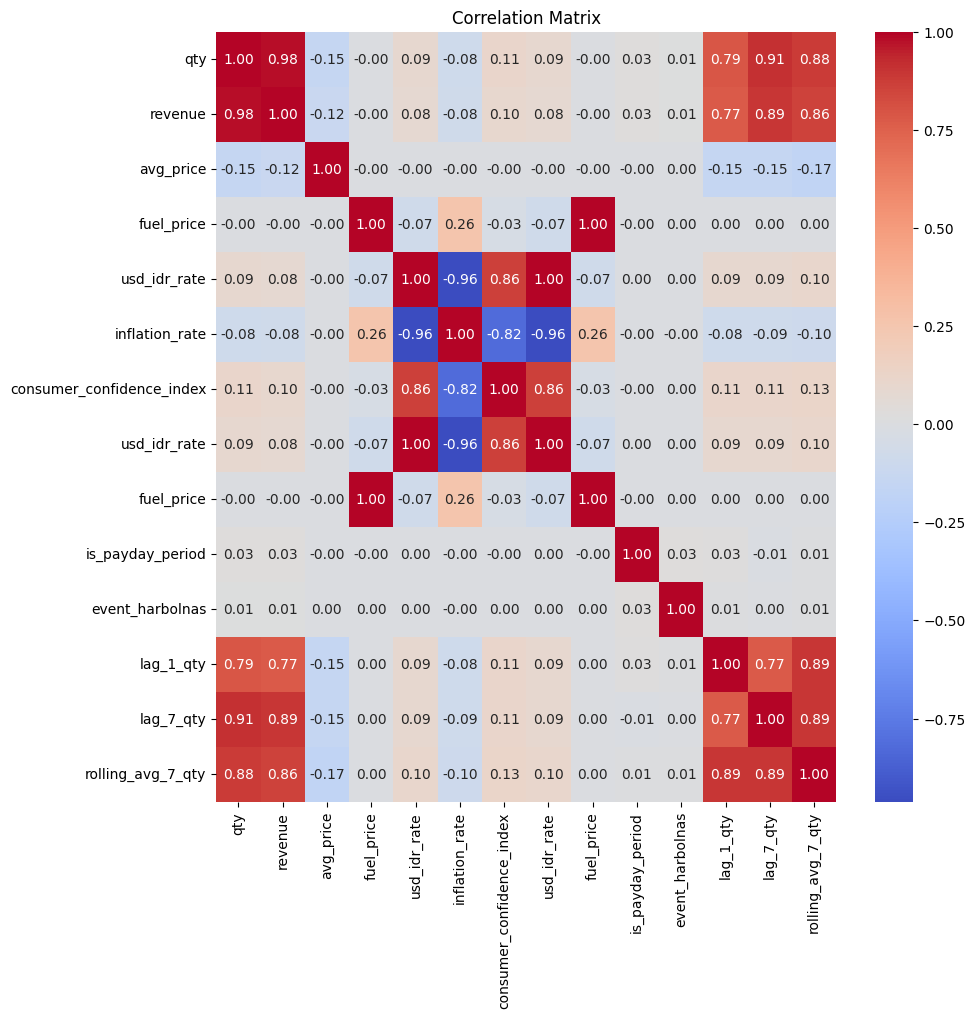

In [29]:
corr = df[cols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

*   qty (Kuantitas) vs revenue (Pendapatan) → Korelasi: 0.98 (Sangat Kuat)
*   inflation_rate vs usd_idr_rate → Korelasi: -0.96 (Sangat Kuat Terbalik
*   inflation_rate vs consumer_confidence_index → Korelasi: -0.82 (Kuat Terbalik)
*   qty & revenue vs Data Historis (lag_7_qty, rolling_avg_7_qty, lag_1_qty) → Korelasi: 0.77 hingga 0.91 (Kuat)

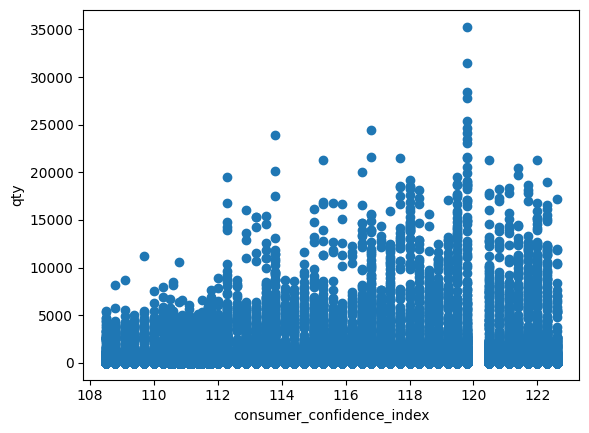

In [30]:
# qty vs consumer confidence index
plt.scatter(df['consumer_confidence_index'], df['qty'])
plt.xlabel('consumer_confidence_index')
plt.ylabel('qty')
plt.show()

In [31]:
df[['qty','consumer_confidence_index']].corr()

,qty,consumer_confidence_index
qty,1.000000,0.110984
consumer_confidence_index,0.110984,1.000000


Indeks Kepercayaan Konsumen vs qty (0.11): Hubungan tergolong sangat lemah. Perubahan psikologis pasar tidak serta-merta mengubah volume pembelian konsumen di toko

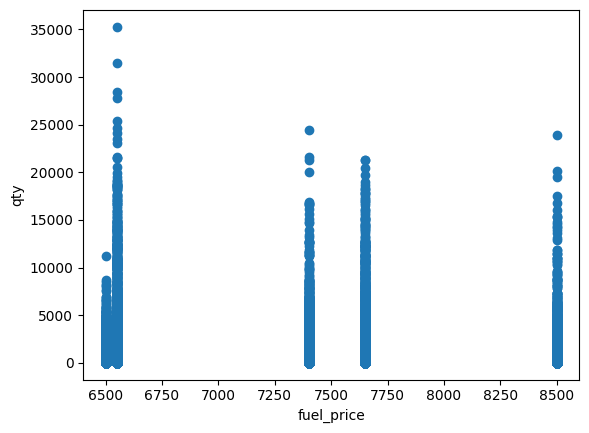

In [32]:
# Pengaruh terhadap fuel price
plt.scatter(df['fuel_price'], df['qty'])
plt.xlabel('fuel_price')
plt.ylabel('qty')
plt.show()

In [33]:
df[['qty','fuel_price']].corr()

,qty,fuel_price
qty,1.000000,-0.000197
fuel_price,-0.000197,1.000000


Harga Bahan Bakar (fuel_price) vs Performa Toko qty (~0.00): Tidak ada korelasi linier sama sekali. Kenaikan harga bahan bakar tidak memengaruhi volume penjualan maupun pendapatan

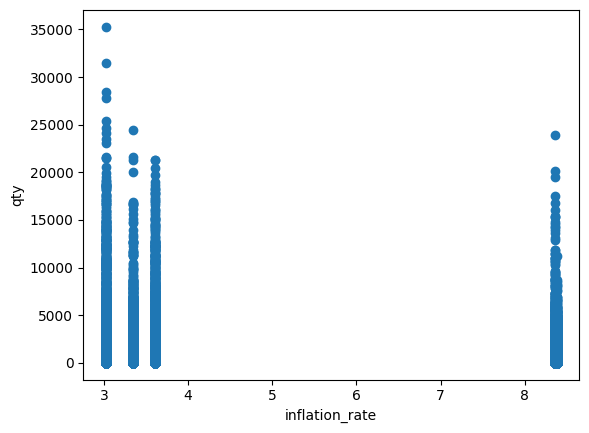

In [34]:
# Pengaruh inflasi
plt.scatter(df['inflation_rate'], df['qty'])
plt.xlabel('inflation_rate')
plt.ylabel('qty')
plt.show()

In [35]:
df[['qty','inflation_rate']].corr()

,qty,inflation_rate
qty,1.000000,-0.083794
inflation_rate,-0.083794,1.000000


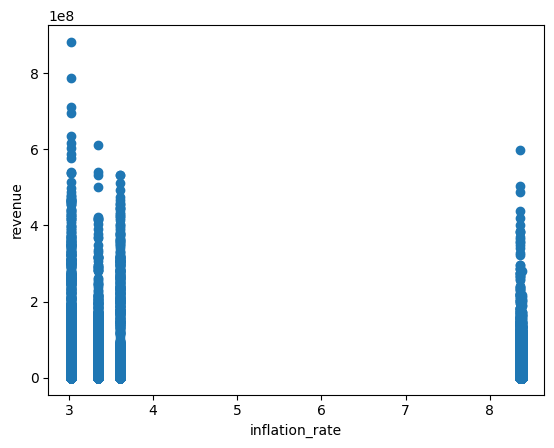

In [36]:
# Pengaruh inflation rate, revenue
plt.scatter(df['inflation_rate'], df['revenue'])
plt.xlabel('inflation_rate')
plt.ylabel('revenue')
plt.show()

In [37]:
df[['inflation_rate','revenue']].corr()

,inflation_rate,revenue
inflation_rate,1.000000,-0.077201
revenue,-0.077201,1.000000


Tingkat Inflasi (inflation_rate) vs Performa Toko (-0.08 untuk qty & -0.07 untuk revenue): Hubungan sangat lemah. Toko menunjukkan performa yang stabil baik pada periode inflasi rendah (~3%) maupun saat inflasi melonjak tinggi (~8.4%).

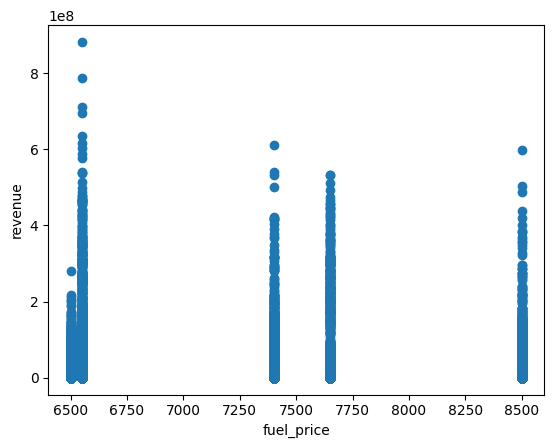

In [38]:
# Pengaruh fuel price, revenue
plt.scatter(df['fuel_price'], df['revenue'])
plt.xlabel('fuel_price')
plt.ylabel('revenue')
plt.show()

In [39]:
df[['fuel_price','revenue']].corr()

,fuel_price,revenue
fuel_price,1.000000,-0.000221
revenue,-0.000221,1.000000


Hubungan linier antara inflasi dan pendapatan tergolong sangat lemah hingga bisa dianggap tidak ada.

In [40]:
print(f"Correlation between Quantity and Consumer Confidence Index: {df['qty'].corr(df['consumer_confidence_index']):.4f}")
print(f"Correlation between fuel price and Consumer Confidence Index: {df['fuel_price'].corr(df['consumer_confidence_index']):.4f}")
print(f"Correlation between inflation and Consumer Confidence Index: {df['inflation_rate'].corr(df['consumer_confidence_index']):.4f}")
print(f"Correlation between Quantity and Fuel Price: {df['qty'].corr(df['fuel_price']):.4f}")
print(f"Correlation between Quantity and Inflation Rate: {df['qty'].corr(df['inflation_rate']):.4f}")
print(f"Correlation between Fuel Price and Revenue: {df['fuel_price'].corr(df['revenue']):.4f}")
print(f"Correlation between Inflation Rate and Revenue: {df['inflation_rate'].corr(df['revenue']):.4f}")

Correlation between Quantity and Consumer Confidence Index: 0.1110
Correlation between fuel price and Consumer Confidence Index: -0.0341
Correlation between inflation and Consumer Confidence Index: -0.8210
Correlation between Quantity and Fuel Price: -0.0002
Correlation between Quantity and Inflation Rate: -0.0838
Correlation between Fuel Price and Revenue: -0.0002
Correlation between Inflation Rate and Revenue: -0.0772


##Problem

Penjualan (qty dan revenue) sangat tidak merata antar waktu dan kategori produk, sehingga sulit memprediksi demand secara akurat dan berpotensi menyebabkan overstock maupun stockout.
Indikasinya:
Median qty hanya 22 unit, tetapi maksimum mencapai 35.279 unit
Rata-rata qty 478 unit dengan standar deviasi 1.538 unit
Revenue median hanya Rp575 ribu, tetapi maksimum mencapai Rp881 juta
Distribusi penjualan sangat skewed (tidak normal)
Artinya sebagian kecil transaksi/periode menyumbang penjualan yang sangat besar, sedangkan mayoritas transaksi relatif kecil

In [41]:
# Melihat mean max dan rata rata
df[['qty','revenue']].describe()

,qty,revenue
count,55572.000000,5.557200e+04
mean,477.613744,1.087810e+07
std,1538.413443,3.688501e+07
min,0.000000,0.000000e+00
25%,1.000000,5.000000e+04
50%,22.000000,5.750000e+05
75%,281.000000,6.650000e+06
max,35279.000000,8.819750e+08


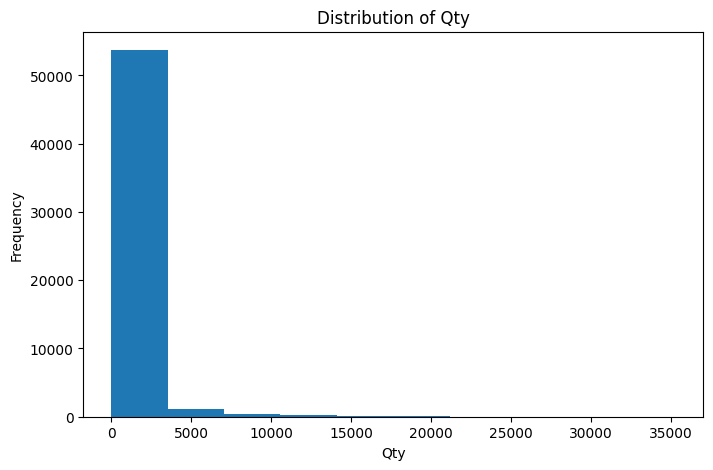

In [42]:
#Histogram QTY
plt.figure(figsize=(8,5))
plt.hist(df["qty"], bins=10)
plt.title("Distribution of Qty")
plt.xlabel("Qty")
plt.ylabel("Frequency")
plt.show()

→ Right Skewed Distribution
Artinya mayoritas transaksi kecil, sedikit transaksi sangat besar

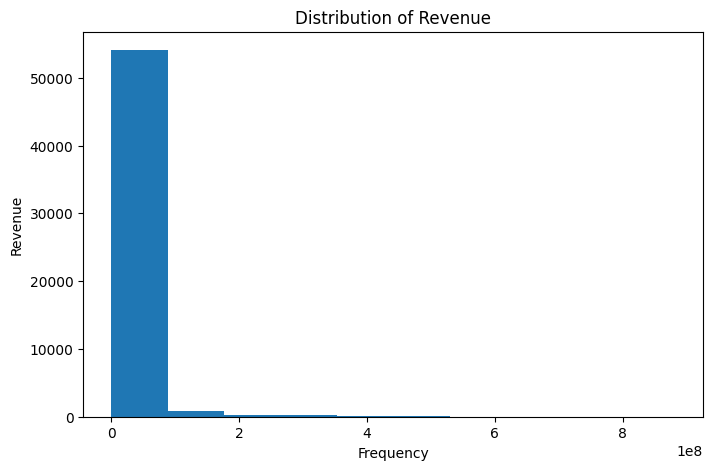

In [43]:
#Histogram Revenue
plt.figure(figsize=(8,5))
plt.hist(df["revenue"], bins=10)
plt.title("Distribution of Revenue")
plt.xlabel("Frequency")
plt.ylabel("Revenue")
plt.show()

In [44]:
print("Skewness Qty :", df["qty"].skew())
print("Skewness Revenue :", df["revenue"].skew())

Skewness Qty : 6.923261594952677
Skewness Revenue : 7.610505685675678


Nilai rata-rata (mean) ditarik secara paksa ke arah kanan oleh data-data pencilan (outliers) tersebut, sehingga nilai rata-rata akan jauh lebih tinggi daripada nilai tengah (median) data yang sebenarnya.
Karakteristik data seperti ini sangat umum ditemukan pada data penjualan retail, di mana performa omzet tahunan sering kali didongkrak secara signifikan oleh segelintir momen high-season (seperti masa libur akhir tahun yang ditemukan pada analisis sebelumnya).

In [45]:
cv_qty = (df["qty"].std() / df["qty"].mean()) * 100
cv_revenue = (df["revenue"].std() / df["revenue"].mean()) * 100

print("\nCV Qty:", round(cv_qty,2), "%")
print("CV Revenue:", round(cv_revenue,2), "%")


CV Qty: 322.1 %
CV Revenue: 339.08 %


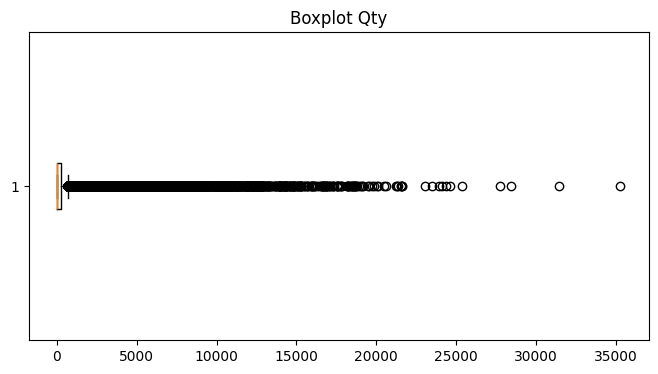

In [46]:
#boxplot
plt.figure(figsize=(8,4))
plt.boxplot(df["qty"], vert=False)
plt.title("Boxplot Qty")
plt.show()

Terdapat transaksi yang outlier

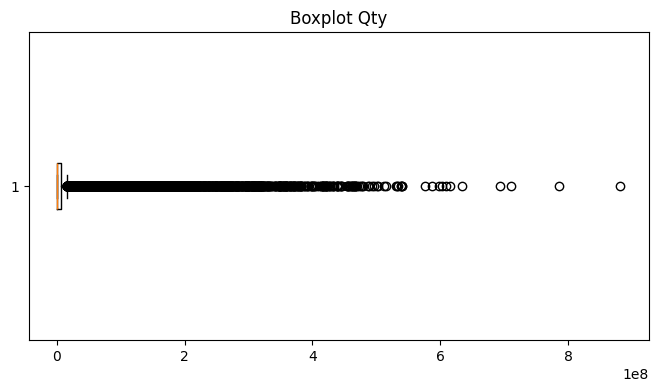

In [47]:
#boxplot
plt.figure(figsize=(8,4))
plt.boxplot(df["revenue"], vert=False)
plt.title("Boxplot Qty")
plt.show()

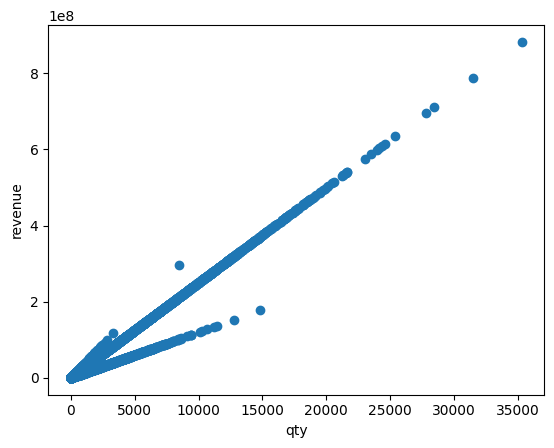

In [51]:
plt.scatter(df['qty'], df['revenue'])
plt.xlabel('qty')
plt.ylabel('revenue')
plt.show()

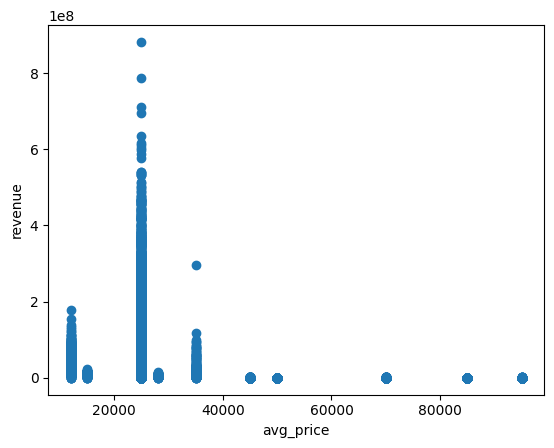

In [52]:
plt.scatter(df['avg_price'], df['revenue'])
plt.xlabel('avg_price')
plt.ylabel('revenue')
plt.show()

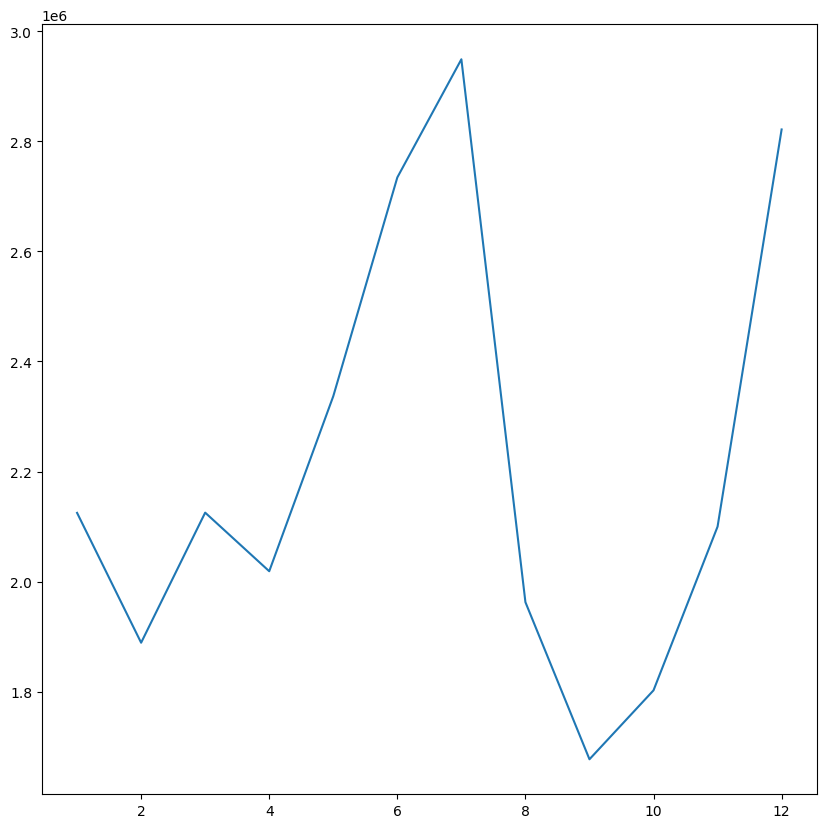

In [107]:
monthly = df.groupby('month')['qty'].sum()
plt.figure(figsize=(10,10))
plt.plot(monthly)
plt.show()

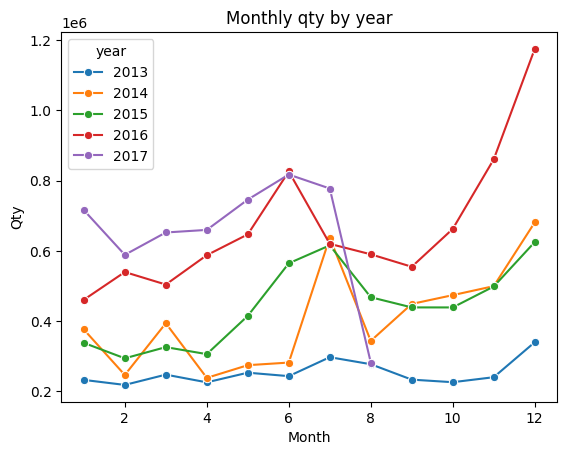

In [108]:
monthly_year = df.groupby(['year', 'month'])['qty'].sum().reset_index()
sns.lineplot(data=monthly_year, x='month', y='qty', hue='year', marker='o', palette='tab10')
plt.xlabel('Month')
plt.ylabel('Qty')
plt.title('Monthly qty by year')
plt.show()

<Axes: xlabel='month'>

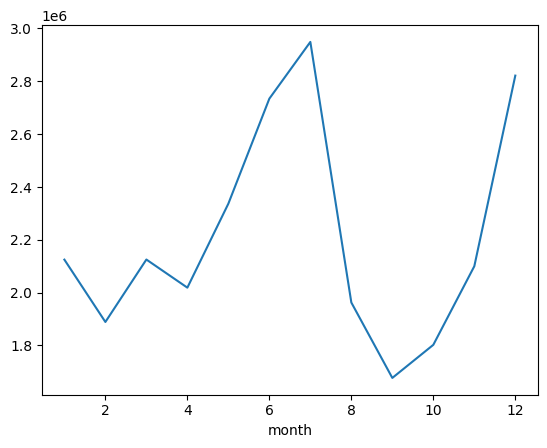

In [109]:
# Tren Penjualan per bulan
monthly_qty = df.groupby('month')['qty'].sum()
monthly_qty.plot()

<Axes: xlabel='day_of_month'>

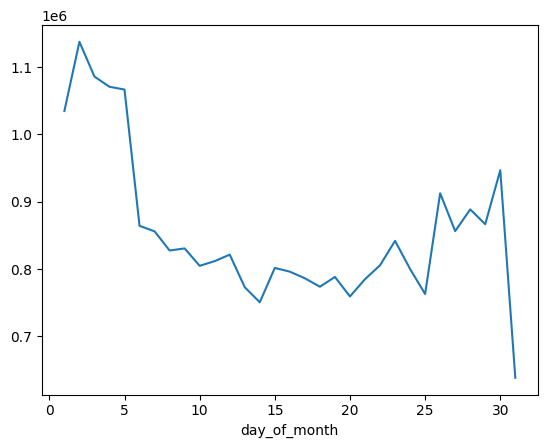

In [110]:
# Tren penjualan per hari
daily_qty = df.groupby('day_of_month')['qty'].sum()
daily_qty.plot()

In [111]:
# Pengaruh event ramadan
df.groupby('event_ramadan')[['qty','revenue']].mean()

,qty,revenue
event_ramadan,,
0,459.629345,1.047007e+07
1,665.654710,1.514431e+07


In [112]:
# Pengaruh event eid
df.groupby('event_eid')[['qty','revenue']].mean()

,qty,revenue
event_eid,,
0,472.735514,1.076463e+07
1,622.098072,1.423860e+07


In [113]:
# Pengaruh payday
df.groupby('is_payday_period')[['qty','revenue']].mean()

,qty,revenue
is_payday_period,,
0,438.732299,9.993007e+06
1,542.828251,1.236262e+07


In [114]:
# Pengaruh Harbolnas
df.groupby('event_harbolnas')[['qty','revenue']].mean()

,qty,revenue
event_harbolnas,,
0,473.683884,1.078861e+07
1,591.860390,1.347959e+07


#ML

In [53]:
df_ml = df.copy()

In [54]:
monthly_Quantity = df.groupby(pd.Grouper(key="date", freq="M"))["qty"].sum()

In [55]:
monthly_Quantity = monthly_Quantity[monthly_Quantity.index < '2017-08-01']

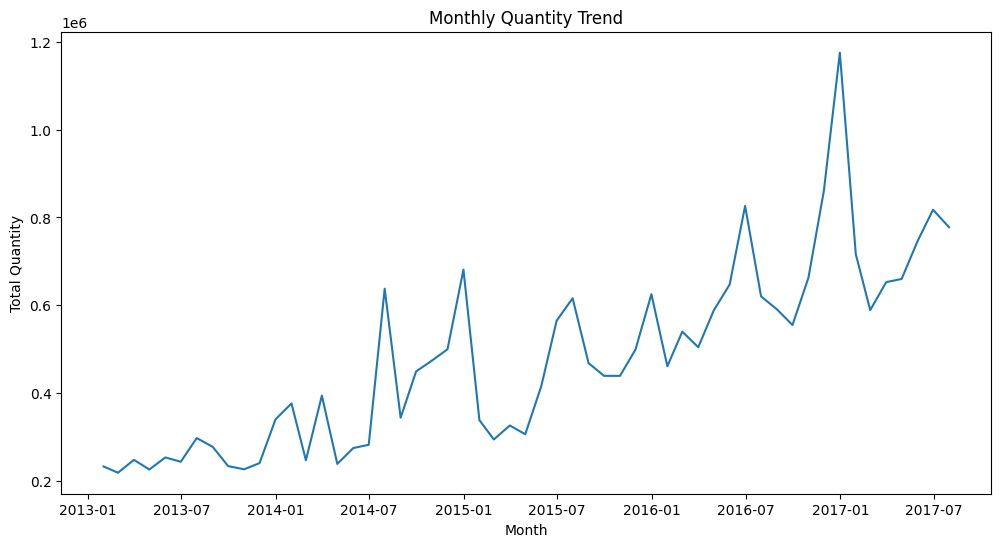

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_Quantity.index, monthly_Quantity.values)
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.title("Monthly Quantity Trend")
plt.show()

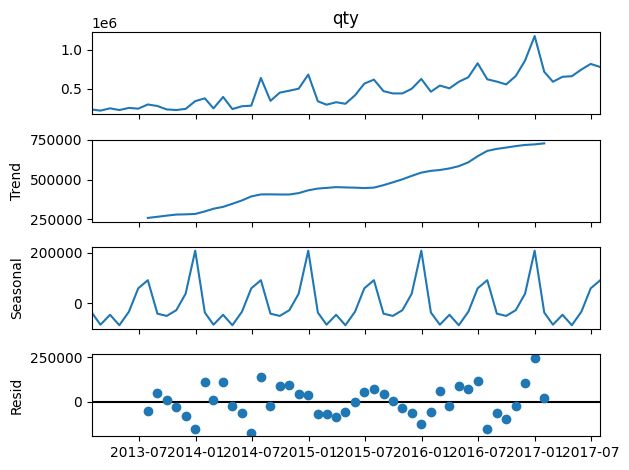

In [57]:
ecomposed = seasonal_decompose(monthly_Quantity, model='additive', period=12)
ecomposed.plot()
plt.show()

In [58]:
monthly_revenue = (df_ml.groupby(pd.Grouper(key='date', freq='MS'))['revenue'].sum())

In [59]:
monthly_revenue = monthly_revenue[monthly_revenue.index < '2017-08-01']

#SPLIT DATA

In [60]:
train_size_qty = int(len(monthly_Quantity) * 0.8)
train_qty = monthly_Quantity[:train_size_qty]
test_qty= monthly_Quantity[train_size_qty:]

In [61]:
train_size_revenue = int(len(monthly_revenue) * 0.8)
train_revenue = monthly_revenue[:train_size_revenue]
test_revenue = monthly_revenue[train_size_revenue:]

#ARIMA

##MONTHLY SALES

In [62]:
auto_model_qty = auto_arima(train_qty, seasonal=False, trace=True)
print(auto_model_qty.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1134.442, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1129.661, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1124.941, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1132.647, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1127.473, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1132.077, Time=0.29 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.45 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1125.388, Time=0.04 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.726 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   44
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -559.471
Date:                Thu, 18 Jun 2026   AIC                

In [63]:
arima_model_qty = ARIMA(train_qty, order=(0,1,1)) # dari nilai best model
arima_fit_qty = arima_model_qty.fit()

In [64]:
arima_pred_qty = arima_fit_qty.forecast(len(test_qty))

In [65]:
arima_future_qty = arima_fit_qty.forecast(steps=12)

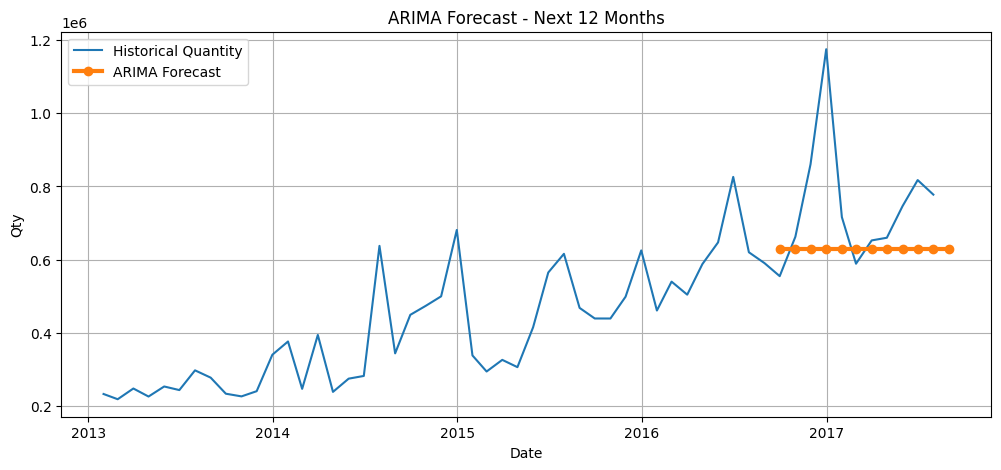

In [66]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_Quantity.index,
    monthly_Quantity.values,
    label='Historical Quantity')
plt.plot(
    arima_future_qty.index,
    arima_future_qty.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast')
plt.title('ARIMA Forecast - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

##MONTHLY REVENUE

In [67]:
auto_model_revenue = auto_arima(train_revenue, seasonal=False, trace=True)
print(auto_model_revenue.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.75 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1996.623, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1992.498, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1987.151, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1994.801, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1990.164, Time=0.10 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1995.136, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1987.761, Time=0.05 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.511 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   44
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -990.575
Date:                Thu, 18 Jun 2026   AIC                

In [68]:
arima_model_revenue = ARIMA(train_revenue, order=(0,1,1)) # dari nilai best model
arima_fit_revenue = arima_model_revenue.fit()

In [69]:
arima_pred_revenue = arima_fit_revenue.forecast(len(test_revenue))

In [70]:
arima_future_revenue = arima_fit_revenue.forecast(steps=12)

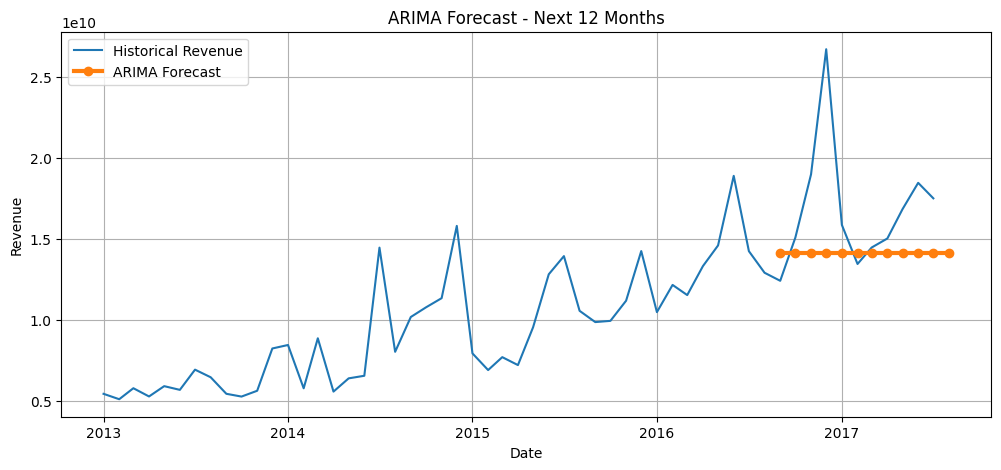

In [71]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    arima_future_revenue.index,
    arima_future_revenue.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast')
plt.title('ARIMA Forecast - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

#SARIMA

##Monthly Sales

In [72]:
auto_arima(train_qty, seasonal=True, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.59 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1134.442, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1126.752, Time=0.63 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1122.057, Time=0.66 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1132.647, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1124.941, Time=0.51 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1122.065, Time=0.71 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1123.271, Time=0.78 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1125.666, Time=0.19 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1123.610, Time=0.76 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1128.640, Time=0.13 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=1124.075, Time=0.18 sec
 ARIMA(0,1,2)(0,0,1)[12] intercept   : AIC=1126.179, Time=0.19 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1123.431, Time=0.11 sec
 ARIMA(1,1,2)(0,0,1)[12]

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True, with_intercept=False)

In [73]:
sarima_model_qty = SARIMAX(train_qty, order=(0,1,1), seasonal_order=(0,0,1,12))
sarima_fit_qty = sarima_model_qty.fit()

In [74]:
sarima_pred_qty = sarima_fit_qty.forecast(len(test_qty))

In [75]:
sarima_future_qty = sarima_fit_qty.forecast(steps=12)

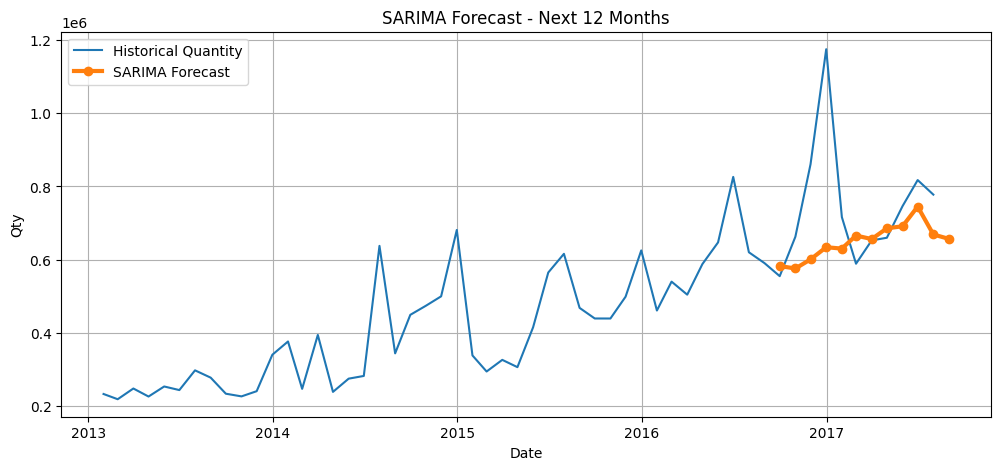

In [76]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_Quantity.index,
    monthly_Quantity.values,
    label='Historical Quantity')
plt.plot(
    sarima_future_qty.index,
    sarima_future_qty.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast')
plt.title('SARIMA Forecast - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

##Revenue Monthly

In [77]:
auto_arima(train_revenue, seasonal=True, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1988.898, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1996.623, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1988.956, Time=0.12 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1983.937, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1994.801, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1987.151, Time=0.04 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1984.272, Time=0.33 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1985.361, Time=0.22 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1987.683, Time=0.14 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1985.781, Time=0.82 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1989.956, Time=0.21 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=1986.026, Time=0.16 sec
 ARIMA(0,1,2)(0,0,1)[12] intercept   : AIC=1988.048, Time=0.26 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1985.555, Time=0.10 sec
 ARIMA(1,1,2)(0,0,1

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True, with_intercept=False)

In [78]:
sarima_model_revenue = SARIMAX(train_revenue, order=(0,1,1), seasonal_order=(0,0,1,12))
sarima_fit_revenue = sarima_model_revenue.fit()

In [79]:
sarima_pred_revenue = sarima_fit_revenue.forecast(len(test_revenue))

In [80]:
sarima_future_revenue = sarima_fit_revenue.forecast(steps=12)

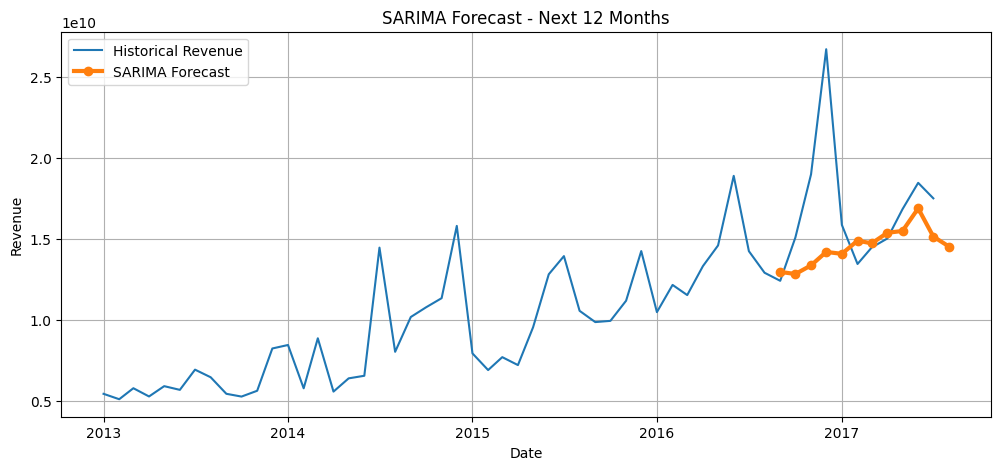

In [81]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    sarima_future_revenue.index,
    sarima_future_revenue.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast')
plt.title('SARIMA Forecast - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

#Holt Winter

##Montlhy Sales

In [82]:
hw_model_qty = ExponentialSmoothing(train_qty, seasonal_periods=12, trend='add', seasonal='add')
hw_fit_qty = hw_model_qty.fit()
hw_pred_qty = hw_fit_qty.forecast(len(test_qty))
hw_future_qty = hw_fit_qty.forecast(12)

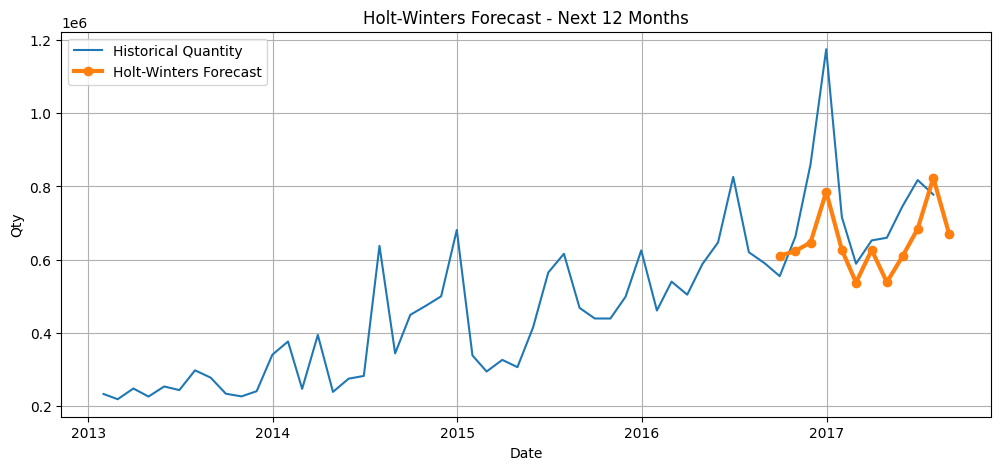

In [83]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_Quantity.index,
    monthly_Quantity.values,
    label='Historical Quantity')
plt.plot(
    hw_future_qty.index,
    hw_future_qty.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

##Monthly Revenue

In [84]:
hw_model_revenue = ExponentialSmoothing(train_revenue, seasonal_periods=12, trend='mul', seasonal='add')
hw_fit_revenue = hw_model_revenue.fit()
hw_pred_revenue = hw_fit_revenue.forecast(len(test_revenue))
hw_future_revenue = hw_fit_revenue.forecast(12)

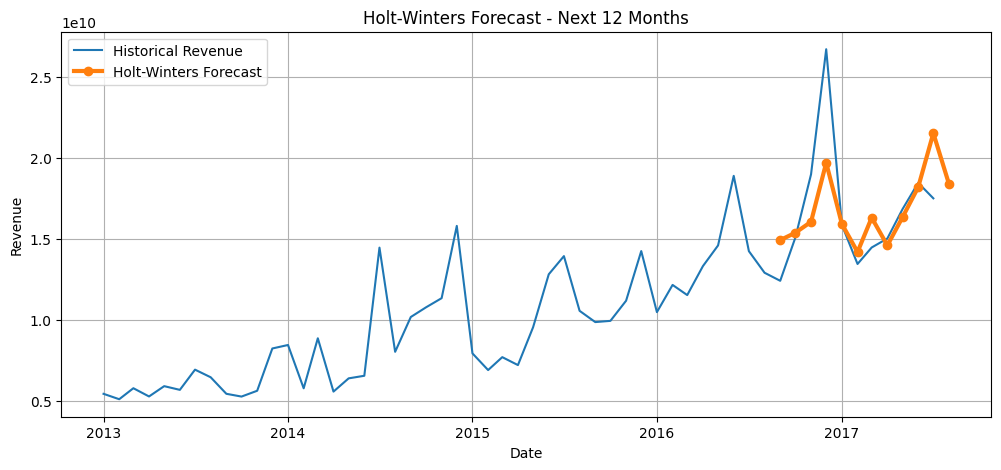

In [85]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    hw_future_revenue.index,
    hw_future_revenue.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast - Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

#Prophet

##Monthly Sales

In [86]:
prophet_train_qty = train_qty.reset_index()
prophet_train_qty.columns = ['ds', 'y']
prophet_model_qty = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_model_qty.fit(prophet_train_qty)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [87]:
future_test_qty = prophet_model_qty.make_future_dataframe(periods=len(test_qty), freq='MS')
forecast_test_qty = prophet_model_qty.predict(future_test_qty)
prophet_pred_qty = forecast_test_qty[['ds', 'yhat']].tail(len(test_qty))
prophet_pred_qty = pd.Series(prophet_pred_qty['yhat'].values, index=test_qty.index)

In [88]:
prophet_full_qty = monthly_Quantity.reset_index()
prophet_full_qty.columns = ['ds', 'y']
prophet_final_qty = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_final_qty.fit(prophet_full_qty)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [89]:
future_qty = prophet_final_qty.make_future_dataframe(periods=12, freq='MS')
forecast_qty = prophet_final_qty.predict(future_qty)
prophet_future_qty = forecast_qty[['ds', 'yhat']].tail(12).set_index('ds')

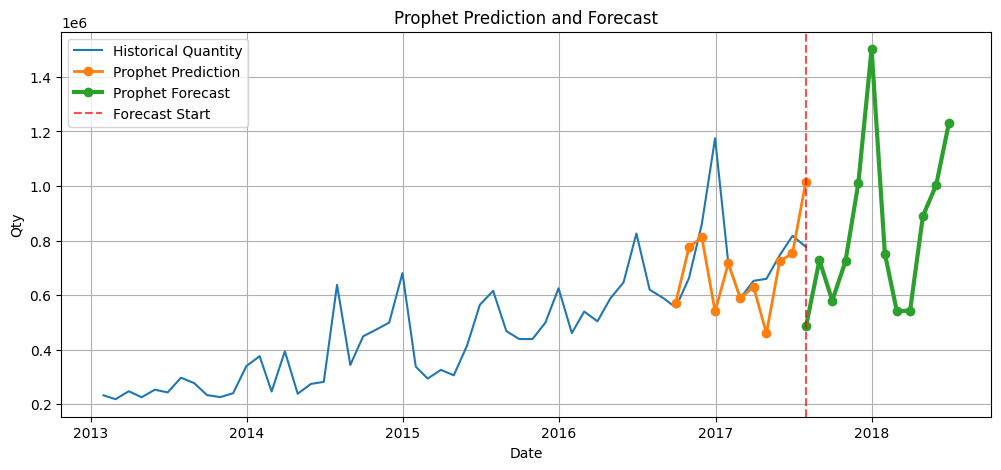

In [90]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_Quantity.index,
    monthly_Quantity.values,
    label='Historical Quantity')

plt.plot(
    prophet_pred_qty.index,
    prophet_pred_qty.values,
    marker='o',
    linewidth=2,
    label='Prophet Prediction')

plt.plot(
    prophet_future_qty.index,
    prophet_future_qty['yhat'],
    marker='o',
    linewidth=3,
    label='Prophet Forecast')

plt.axvline(
    monthly_Quantity.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start')

plt.title('Prophet Prediction and Forecast')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)
plt.show()

#Monthly Revenue

In [91]:
prophet_train_revenue = train_revenue.reset_index()
prophet_train_revenue.columns = ['ds', 'y']
prophet_model_revenue = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_model_revenue.fit(prophet_train_revenue)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [92]:
future_test_revenue = prophet_model_revenue.make_future_dataframe(periods=len(test_revenue), freq='MS')
forecast_test_revenue = prophet_model_revenue.predict(future_test_revenue)
prophet_pred_revenue = forecast_test_revenue[['ds', 'yhat']].tail(len(test_revenue))
prophet_pred_revenue = pd.Series(prophet_pred_revenue['yhat'].values, index=test_revenue.index)

In [93]:
prophet_full_revenue = monthly_revenue.reset_index()
prophet_full_revenue.columns = ['ds', 'y']
prophet_final_revenue = Prophet(seasonality_mode='multiplicative',
                      seasonality_prior_scale=15,
                      yearly_seasonality=True)
prophet_final_revenue.fit(prophet_full_revenue)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [94]:
future_revenue = prophet_final_revenue.make_future_dataframe(periods=12, freq='MS')
forecast_revenue = prophet_final_revenue.predict(future_revenue)
prophet_future_revenue = forecast_revenue[['ds', 'yhat']].tail(12).set_index('ds')

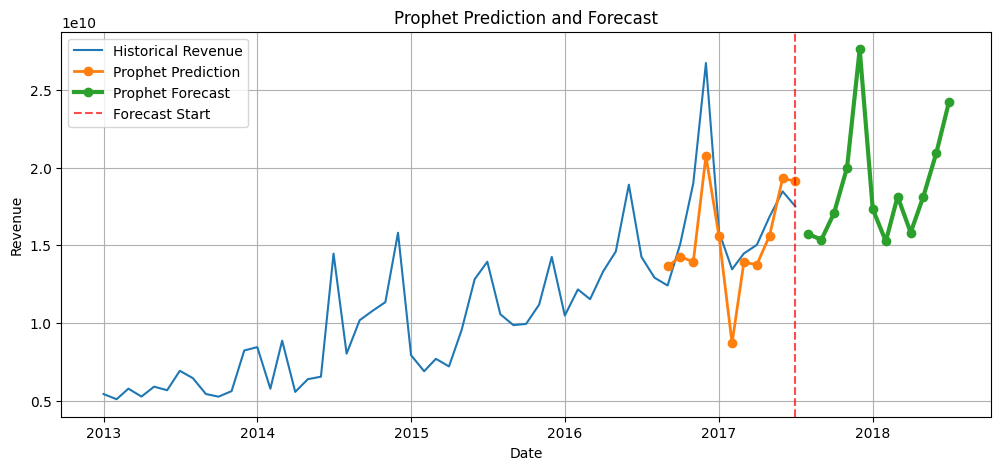

In [95]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')

plt.plot(
    prophet_pred_revenue.index,
    prophet_pred_revenue.values,
    marker='o',
    linewidth=2,
    label='Prophet Prediction')

plt.plot(
    prophet_future_revenue.index,
    prophet_future_revenue['yhat'],
    marker='o',
    linewidth=3,
    label='Prophet Forecast')

plt.axvline(
    monthly_revenue.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start')

plt.title('Prophet Prediction and Forecast')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

#EVALUASI

In [96]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, mape
results = []

results.append(
    ["ARMA", *evaluate(test_qty, arima_pred_qty)]
)

results.append(
    ["SARIMA", *evaluate(test_qty, sarima_pred_qty)]
)

results.append(
    ["Holt Winter", *evaluate(test_qty, hw_pred_qty)]
)

results.append(
    ["Prophet", *evaluate(test_qty, prophet_pred_qty)]
)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results

,Model,MAE,RMSE,MAPE
0,ARMA,137517.235587,199374.883597,15.993035
1,SARIMA,122174.097510,191312.975965,14.007074
2,Holt Winter,118387.999367,155782.177061,14.366167
3,Prophet,123516.782398,217260.828706,14.075066


In [97]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, mape
results = []

results.append(
    ["ARMA", *evaluate(test_revenue, arima_pred_revenue)]
)

results.append(
    ["SARIMA", *evaluate(test_revenue, sarima_pred_revenue)]
)

results.append(
    ["Holt Winter", *evaluate(test_revenue, hw_pred_revenue)]
)

results.append(
    ["Prophet", *evaluate(test_revenue, prophet_pred_revenue)]
)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results

,Model,MAE,RMSE,MAPE
0,ARMA,3.089416e+09,4.534324e+09,15.899842
1,SARIMA,2.734863e+09,4.361800e+09,13.819485
2,Holt Winter,1.875137e+09,2.777932e+09,10.254863
3,Prophet,2.149669e+09,2.907658e+09,12.262954


#GRAFIK

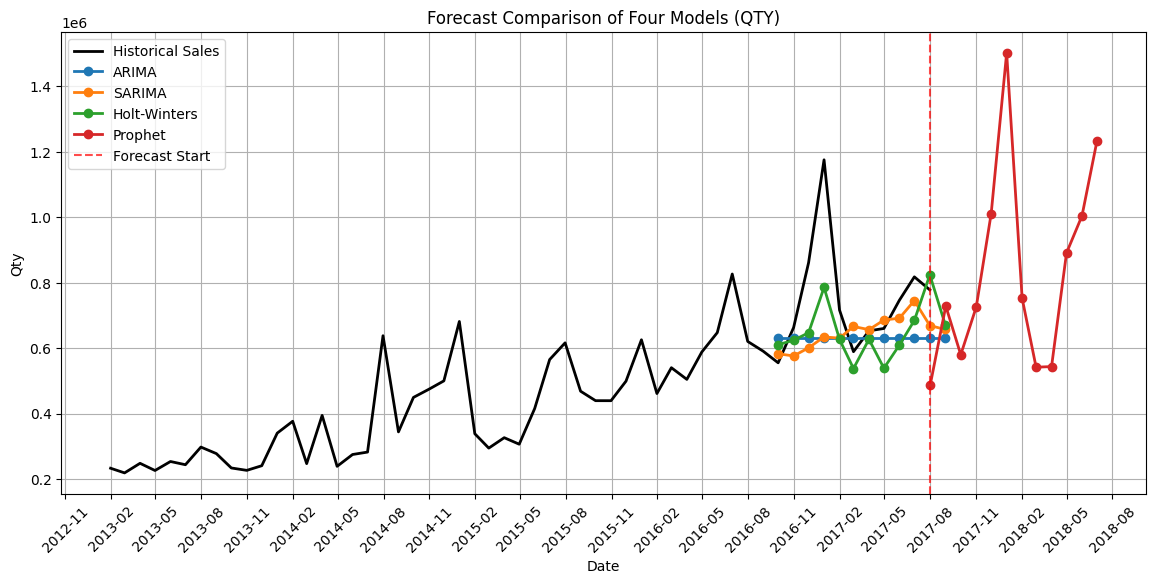

In [98]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_Quantity.index,
    monthly_Quantity.values,
    color='black',
    linewidth=2,
    label='Historical Sales'
)

# ARIMA
plt.plot(
    arima_future_qty.index,
    arima_future_qty.values,
    marker='o',
    linewidth=2,
    label='ARIMA'
)

# SARIMA
plt.plot(
    sarima_future_qty.index,
    sarima_future_qty.values,
    marker='o',
    linewidth=2,
    label='SARIMA'
)

# Holt-Winters
plt.plot(
    hw_future_qty.index,
    hw_future_qty.values,
    marker='o',
    linewidth=2,
    label='Holt-Winters'
)

# Prophet
plt.plot(
    prophet_future_qty.index,
    prophet_future_qty['yhat'],
    marker='o',
    linewidth=2,
    label='Prophet'
)

plt.axvline(
    monthly_Quantity.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start'
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.title('Forecast Comparison of Four Models (QTY)')
plt.xlabel('Date')
plt.ylabel('Qty')
plt.legend()
plt.grid(True)

plt.show()

In [99]:
prop_tabel = pd.DataFrame({
    'Date': prophet_future_qty.index.strftime('%b-%Y'),
    'Forecast_Qty': prophet_future_qty['yhat'].values
})

prop_tabel

,Date,Forecast_Qty
0,Aug-2017,4.885446e+05
1,Sep-2017,7.282921e+05
2,Oct-2017,5.796939e+05
3,Nov-2017,7.250267e+05
4,Dec-2017,1.010755e+06
5,Jan-2018,1.501490e+06
6,Feb-2018,7.524340e+05
7,Mar-2018,5.414873e+05
8,Apr-2018,5.434444e+05
9,May-2018,8.905036e+05


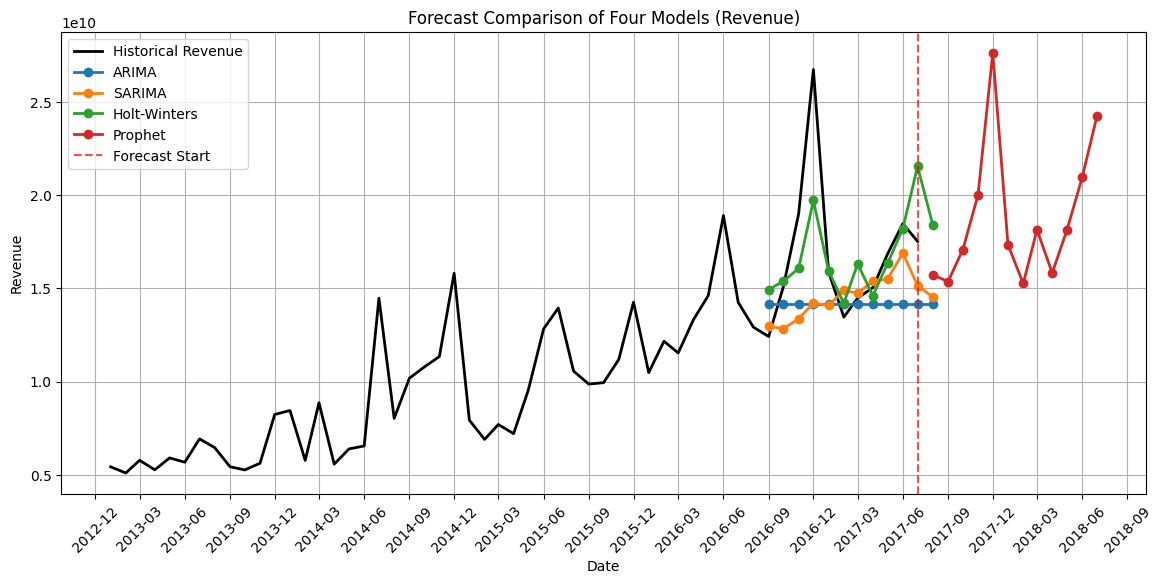

In [100]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color='black',
    linewidth=2,
    label='Historical Revenue'
)

# ARIMA
plt.plot(
    arima_future_revenue.index,
    arima_future_revenue.values,
    marker='o',
    linewidth=2,
    label='ARIMA'
)

# SARIMA
plt.plot(
    sarima_future_revenue.index,
    sarima_future_revenue.values,
    marker='o',
    linewidth=2,
    label='SARIMA'
)

# Holt-Winters
plt.plot(
    hw_future_revenue.index,
    hw_future_revenue.values,
    marker='o',
    linewidth=2,
    label='Holt-Winters'
)

# Prophet
plt.plot(
    prophet_future_revenue.index,
    prophet_future_revenue['yhat'],
    marker='o',
    linewidth=2,
    label='Prophet'
)

plt.axvline(
    monthly_revenue.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start'
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.title('Forecast Comparison of Four Models (Revenue)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)

plt.show()

In [101]:
hw_tabel = pd.DataFrame({
    'Date': hw_future_revenue.index.strftime('%b-%Y'),
    'Forecast_Revenue': hw_future_revenue.values
})

hw_tabel

,Date,Forecast_Revenue
0,Sep-2016,1.492925e+10
1,Oct-2016,1.538250e+10
2,Nov-2016,1.605866e+10
3,Dec-2016,1.970829e+10
4,Jan-2017,1.592599e+10
5,Feb-2017,1.419196e+10
6,Mar-2017,1.631601e+10
7,Apr-2017,1.460018e+10
8,May-2017,1.633902e+10
9,Jun-2017,1.819504e+10


#DATA FINAL FORECAST

In [102]:
qty_full = monthly_Quantity.reset_index()
qty_full.columns = ['ds','y']

prophet_final_qty = Prophet()

prophet_final_qty.fit(
    qty_full
)

future_qty = prophet_final_qty.make_future_dataframe(
    periods=12,
    freq='MS'
)

prophet_future_qty = prophet_final_qty.predict(
    future_qty
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [103]:
hw_final_revenue = ExponentialSmoothing(
    monthly_revenue,
    trend='mul',
    seasonal='add',
    seasonal_periods=12
)

hw_final_fit_revenue = hw_final_revenue.fit()

hw_final_future_revenue = hw_final_fit_revenue.forecast(12)

In [104]:
future_dates = pd.date_range(
    start=monthly_revenue.index[-1]
          + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

hw_final_future_revenue.index = future_dates

In [105]:
forecast_final = pd.DataFrame({
    'Date':
        prophet_future_qty['ds']
        .tail(12)
        .values,

    'Forecast_Qty':
        prophet_future_qty['yhat']
        .tail(12)
        .round(0)
        .values,

    'Forecast_Revenue':
        hw_final_future_revenue
        .round(0)
        .values
})

forecast_final

,Date,Forecast_Qty,Forecast_Revenue
0,2017-08-01,593269.0,1.831838e+10
1,2017-09-01,762137.0,1.868341e+10
2,2017-10-01,640367.0,1.908050e+10
3,2017-11-01,725123.0,1.999081e+10
4,2017-12-01,902202.0,2.353518e+10
5,2018-01-01,1240591.0,1.985147e+10
6,2018-02-01,810092.0,1.942466e+10
7,2018-03-01,655025.0,2.077822e+10
8,2018-04-01,661295.0,2.035230e+10
9,2018-05-01,856348.0,2.198502e+10


In [106]:
forecast_final.to_csv(
    'forecast_final.csv',
    index=False
)